# Kapitel 1 – Iris: erster ML-Workflow mit scikit-learn

In diesem Notebook sehen wir einen ersten vollständigen Workflow des **überwachten** Lernens:
1. Datensatz laden
2. Trainings- und Testdaten bilden
3. Modell trainieren
4. Vorhersagen berechnen
5. Modell bewerten

## Lernziele
Nach diesem Notebook können Sie:
- `X` und `y` im ML-Kontext erklären,
- einen Train/Test-Split durchführen,
- ein erstes Klassifikationsmodell trainieren,
- Vorhersagen interpretieren,
- Accuracy als erste Metrik einordnen.


**Dozentenversion mit Musterlösung**

Diese Fassung enthält zusätzliche Lösungshinweise zu den Diskussionsfragen und Beispielantworten zu den Mini-Aufgaben.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


## Abschnitt 1 – Iris-Daten laden


In [2]:
iris = load_iris()
X = iris.data
y = iris.target

print("Form von X:", X.shape)
print("Form von y:", y.shape)


Form von X: (150, 4)
Form von y: (150,)


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species_id"] = y
df["species_name"] = [iris.target_names[i] for i in y]

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Abschnitt 2 – Was bedeuten `X` und `y`?

- `X` enthält die **Features** (Merkmale)
- `y` enthält die **Labels** (Zielklassen)

Beim **überwachten** Lernen lernt das Modell einen Zusammenhang zwischen `X` und `y`.


In [4]:
print("Erstes Sample in X:", X[0])
print("Erstes Label in y:", y[0], "->", iris.target_names[y[0]])


Erstes Sample in X: [5.1 3.5 1.4 0.2]
Erstes Label in y: 0 -> setosa


## Abschnitt 3 – Erste Visualisierung

Wir betrachten nur die ersten beiden Merkmale.  
Wichtig: Der Plot zeigt **nicht alle 4 Merkmale**, sondern nur einen zweidimensionalen Ausschnitt.


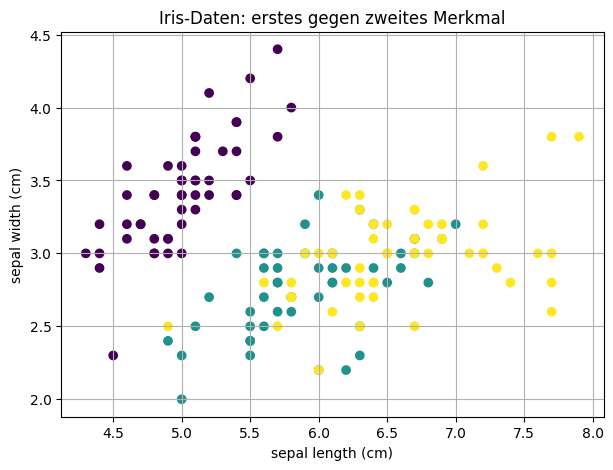

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Iris-Daten: erstes gegen zweites Merkmal")
plt.grid(True)
plt.show()


## ⚠️ Achtung – häufige Verwechslung: Wie werden die Punkte eingefärbt?

Dieser Plot verwendet **nicht** `hue` wie bei seaborn, sondern den
Parameter `c=y` aus **Matplotlib**.

### Was macht `c=y`?

`c` steht für **color**. Hier wird das Ziel-Array `y` übergeben –
also die Klassennummern `[0, 0, ..., 1, 1, ..., 2, 2, ...]`.

Matplotlib färbt die Punkte dann automatisch anhand dieser Zahlen ein:

| Zahl in `y` | Iris-Art    | Farbe  |
|-------------|-------------|--------|
| 0           | setosa      | 🟣 lila  |
| 1           | versicolor  | 🩵 türkis |
| 2           | virginica   | 🟡 gelb  |

### Warum fehlt die Legende?

`c=y` übergibt nur **Zahlen** – Matplotlib kennt die Namen
„setosa", „versicolor", „virginica" nicht.
Deshalb erscheint **keine automatische Legende** mit Klassennamen.

### Vergleich: Matplotlib vs. Seaborn

|                  | `plt.scatter(c=y)`        | `sns.scatterplot(hue="species")` |
|------------------|---------------------------|----------------------------------|
| Eingabe          | Zahlen-Array              | Spaltenname im DataFrame         |
| Legende          | ❌ keine                  | ✅ automatisch mit Namen         |
| Farben           | automatische Farbskala    | kategorische Farben              |

### Merksatz:
> `c=y` und `hue="species"` **sehen ähnlich aus, funktionieren aber
> grundlegend anders.** Im echten Projekt bevorzugt man seaborn mit `hue`,
> weil die Legende automatisch korrekt beschriftet wird.

## Abschnitt 4 – Trainings- und Testdaten bilden

Warum teilen wir die Daten auf?  
Damit wir prüfen können, wie gut das Modell auf **unbekannten Daten** funktioniert.

Wir verwenden `stratify=y`, damit alle Klassen in Train und Test ähnlich verteilt bleiben.

## Warum `stratify=y`?

Ohne `stratify` könnte der Zufall dazu führen, dass eine Klasse
im Testset über- oder unterrepräsentiert ist → verfälschtes Ergebnis.

Mit `stratify=y` wird die Klassenverteilung aus dem Original
**proportional** auf Train und Test übertragen.

- 70% der Daten → Training  (105 Samples, je 35 pro Klasse)
- 30% der Daten → Test      (45 Samples,  je 15 pro Klasse)

Merksatz: Immer `stratify=y` verwenden bei Klassifikationsaufgaben!


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (105, 4)
X_test : (45, 4)
y_train: (105,)
y_test : (45,)


## Abschnitt 5 – Modell initialisieren und trainieren

Wir verwenden einen **k-Nächste-Nachbarn-Klassifikator** (`KNeighborsClassifier`) mit `n_neighbors=3`.


In [7]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

print("Das Modell wurde trainiert.")


Das Modell wurde trainiert.


## Abschnitt 6 – Vorhersagen auf Testdaten


In [8]:
y_pred = model.predict(X_test)

print("Erste 10 Vorhersagen:", y_pred[:10])
print("Erste 10 echte Labels:", y_test[:10])


Erste 10 Vorhersagen: [2 1 1 1 2 2 1 1 0 2]
Erste 10 echte Labels: [2 1 2 1 2 2 1 1 0 2]


## Abschnitt 7 – Modell bewerten

Die **Accuracy** gibt an, welcher Anteil der Testbeispiele korrekt klassifiziert wurde.

Wichtig: Eine hohe Accuracy ist ein guter erster Hinweis, aber noch **keine vollständige Modellbewertung**.


In [9]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy auf den Testdaten:", round(acc, 4))


Accuracy auf den Testdaten: 0.9556


## Optionaler Ausblick – Konfusionsmatrix

Die Konfusionsmatrix zeigt, welche Klassen richtig bzw. falsch vorhergesagt wurden.


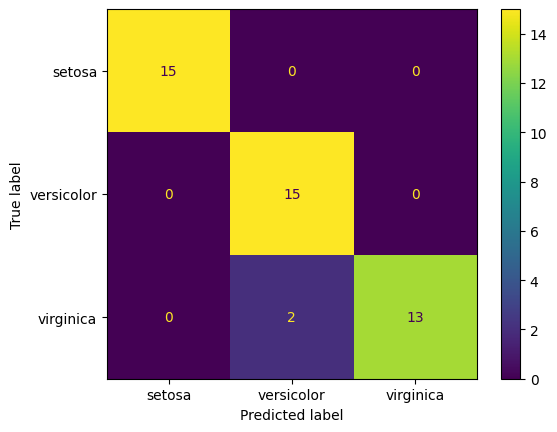

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.show()


## Abschnitt 8 – Eine neue Blume klassifizieren


In [11]:
neue_blume = np.array([[5.1, 3.5, 1.4, 0.2]])
vorhersage = model.predict(neue_blume)[0]

print("Vorhersagte Klasse:", vorhersage)
print("Vorhersagter Klassenname:", iris.target_names[vorhersage])


Vorhersagte Klasse: 0
Vorhersagter Klassenname: setosa


## Diskussionsfragen mit Musterantworten

1. **Warum teilen wir in Trainings- und Testdaten auf?**  
   Damit wir prüfen können, ob das Modell auch auf bisher unbekannten Daten gut funktioniert.

2. **Was lernen `fit()` und `predict()`?**  
   `fit()` passt das Modell an Trainingsdaten an. `predict()` erzeugt Vorhersagen für neue oder bekannte Eingabedaten.

3. **Warum ist eine hohe Trainingsgüte allein nicht ausreichend?**  
   Ein Modell kann Trainingsdaten auswendig lernen. Entscheidend ist die Generalisierung auf neue Daten.

4. **Welche Rolle spielt `random_state`?**  
   Er macht die Datenaufteilung reproduzierbar, sodass Ergebnisse im Unterricht nachvollziehbar bleiben.


## Mini-Aufgaben im Unterricht

**Aufgabe 1:** Ändern Sie `n_neighbors` auf 1, 5 und 10.  
Wie verändert sich die Accuracy?

**Aufgabe 2:** Verwenden Sie nur die ersten beiden Features:
```python
X2 = X[:, :2]
```
Wird das Modell besser oder schlechter?

**Aufgabe 3:** Testen Sie eine eigene neue Blume.


## Musterlösungen zu den Mini-Aufgaben

Die folgenden Lösungen sind Beispiele. Je nach Split können sich einzelne Werte leicht unterscheiden.


In [ ]:
# Musterlösung 1: n_neighbors variieren
for k in [1, 5, 10]:
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train, y_train)
    y_pred_k = model_k.predict(X_test)
    print(f"k = {k}: Accuracy = {accuracy_score(y_test, y_pred_k):.3f}")


In [ ]:
# Musterlösung 2: Nur die ersten beiden Features verwenden
X2 = X[:, :2]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y
)

model2 = KNeighborsClassifier(n_neighbors=3)
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

print("Accuracy mit 2 Features:", accuracy_score(y2_test, y2_pred))


In [ ]:
# Musterlösung 3: Neue Blume klassifizieren
neue_blume = np.array([[6.0, 2.9, 4.5, 1.5]])
vorhersage = model.predict(neue_blume)[0]
print("Vorhersagte Klasse:", vorhersage)
print("Vorhersagter Klassenname:", iris.target_names[vorhersage])
